In [1]:
# !pip install "tensorflow-text==v2.15.0"
# !pip install einops

In [2]:
import numpy as np
import pandas as pd

import typing
from typing import Any, Tuple

import matplotlib.pyplot as plt
import seaborn as sns

import einops
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import tensorflow as tf
import tensorflow_text as tf_text

from tensorflow import keras 
from tensorflow.keras.models import Model

2025-08-06 06:55:47.264501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754463347.574788      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754463347.673706      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
#@title
class ShapeChecker():
  def __init__(self):
    # Keep a cache of every axis-name seen
    self.shapes = {}

  def __call__(self, tensor, names, broadcast=False):
    if not tf.executing_eagerly():
      return

    parsed = einops.parse_shape(tensor, names)
    # tf.print("ShapeChecker:", names, "→", parsed)


    for name, new_dim in parsed.items():
      old_dim = self.shapes.get(name, None)
      
      if (broadcast and new_dim == 1):
        continue

      if old_dim is None:
        # If the axis name is new, add its length to the cache.
        self.shapes[name] = new_dim
        continue

      if new_dim != old_dim:
        raise ValueError(f"Shape mismatch for dimension: '{name}'\n"
                         f"    found: {new_dim}\n"
                         f"    expected: {old_dim}\n")

## Read the file

In [4]:
train_csv = "/kaggle/input/alt-eng-id/asian_treebank_train_short.csv"
val_csv   = "/kaggle/input/alt-eng-id/asian_treebank_val_short.csv"
test_csv  = "/kaggle/input/alt-eng-id/asian_treebank_test_short.csv"

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print(f"train data: {len(train_df)}")
print(f"val data: {len(val_df)}")
print(f"test data: {len(test_df)}")

train data: 12956
val data: 1620
test data: 1620


In [5]:
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    missing = df[['en','id']].isna().sum()
    print(f"{split_name} missing values:\n{missing}\n")


train missing values:
en    0
id    0
dtype: int64

val missing values:
en    0
id    0
dtype: int64

test missing values:
en    0
id    0
dtype: int64



In [6]:
print("Columns with any NaNs in test_df:", test_df.columns[test_df.isna().any()].tolist())
print("Rows with en missing in test_df:")
print(test_df[test_df['en'].isna()])

Columns with any NaNs in test_df: []
Rows with en missing in test_df:
Empty DataFrame
Columns: [SNT.URLID, SNT.URLID.SNTID, url, en, id, value]
Index: []


In [7]:
test_df = test_df[~test_df['en'].isna()]

In [8]:
print(test_df[test_df['en'].isna()])

Empty DataFrame
Columns: [SNT.URLID, SNT.URLID.SNTID, url, en, id, value]
Index: []


In [9]:
context_train = train_df["en"].astype(str).values
target_train  = train_df["id"].astype(str).values

context_val   = val_df["en"].astype(str).values
target_val    = val_df["id"].astype(str).values

context_test  = test_df["en"].astype(str).values
target_test   = test_df["id"].astype(str).values

context_train = np.array(context_train)
target_train  = np.array(target_train)
context_val   = np.array(context_val)
target_val    = np.array(target_val)
context_test  = np.array(context_test)
target_test   = np.array(target_test)

In [10]:
context_raw = (
    list(train_df["en"].astype(str)) +
    list(val_df  ["en"].astype(str)) +
    list(test_df ["en"].astype(str))
)
target_raw  = (
    list(train_df["id"].astype(str)) +
    list(val_df  ["id"].astype(str)) +
    list(test_df ["id"].astype(str))
)

#––– (Optionally) verify lengths match –––
assert len(context_raw) == len(target_raw)
print(f"Total examples: {len(context_raw)}")

Total examples: 16196


In [11]:
context_raw[:3]

['The case was prosecuted in Virginia because it is the home to the leading internet service provider AOL, the company who instigated the charges.',
 "Playing in Australia's top level domestic league, the W-League, she won the league championship in 2009.",
 "A clue could be to look to the U.S. where HBO's niche channels include HBO Family for children-friendly programming and the self-explanatory HBO Comedy channel."]

## Word distribution 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


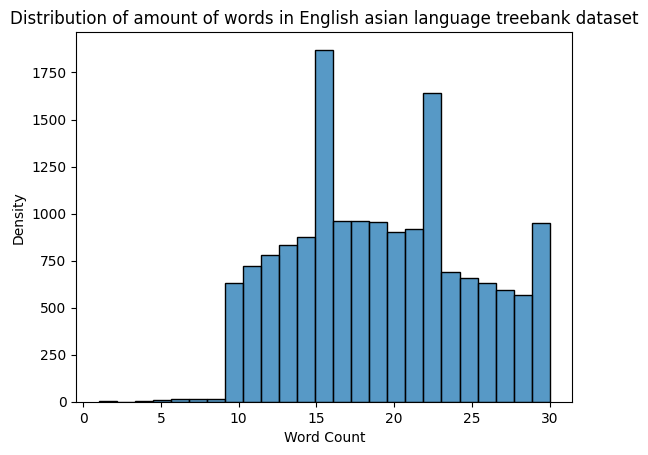

Maximum: 30, Minimum: 1


In [12]:
eng_word_counts = [len(s.split()) for s in context_raw]

plt.figure()
# sns.histplot(eng_word_counts, bins='auto', kde=True, stat='density')
sns.histplot(eng_word_counts, bins=25, kde=False)
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.title('Distribution of amount of words in English asian language treebank dataset')
plt.show()

print(f"Maximum: {max(eng_word_counts)}, Minimum: {min(eng_word_counts)}")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


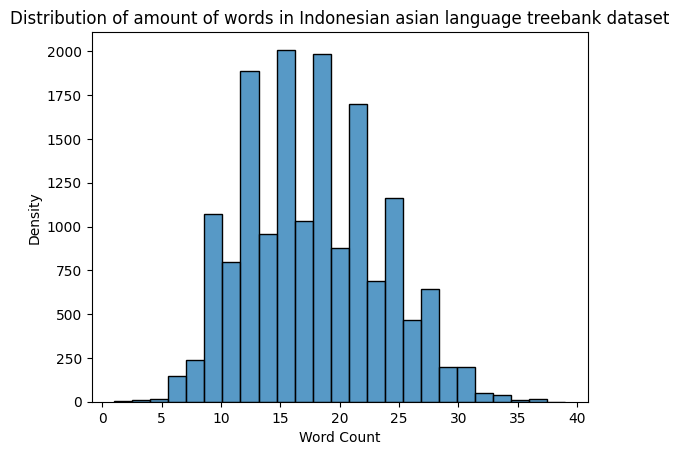

Maximum: 39, Minimum: 1


In [13]:
id_word_counts = [len(s.split()) for s in target_raw]

plt.figure()
# sns.histplot(id_word_counts, bins='auto', kde=True, stat='density')
sns.histplot(id_word_counts, bins=25, kde=False)
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.title('Distribution of amount of words in Indonesian asian language treebank dataset')
plt.show()

print(f"Maximum: {max(id_word_counts)}, Minimum: {min(id_word_counts)}")

In [14]:
# # def get_longest_sentence(amount=1, )
# amount=3

# sents = []

# longest_context = max(eng_word_counts)
# # print(longest_context)
# keep_search = (amount ==  len(sents))

# while(keep_search):
#     found = False
#     for i, content in enumerate(context_raw):
#         if len(sents) == amount:
#             break
        
#         if len(content.split()) == longest_context:
#             if content:
#                 if content in sents:
#                     continue
#                 else:
#                     print(i, content)
#                     print()
#                     sents.append(content)
#                     found = True
#                     longest_context-=1
                
    
#             # else:
#             #     print('Not found.')
    
#         # else:
#         #     print('Not found')
#     if not found: 
#         print('Not found.')
#         longest_context-=1
        

# #TODO: PLOT ATTENTION ON LONG SENTENCES

# # for sent in sents:
# #     print(sent)

# print(len(sents))

In [15]:
def get_longest_with_targets(context_raw, target_raw, amount):
    if len(context_raw) != len(target_raw):
        raise ValueError("context_raw and target_raw must have the same length")
    
    # Build a list of (index, sentence, word_count)
    indexed = [
        (i, sent, len(sent.split())) 
        for i, sent in enumerate(context_raw)
    ]
    # Sort by descending word count
    indexed.sort(key=lambda x: x[2], reverse=True)
    
    selected_indices = []
    seen = set()
    for i, sent, count in indexed:
        if sent not in seen:
            selected_indices.append(i)
            seen.add(sent)
            if len(selected_indices) == amount:
                break
    
    # Gather the contexts and their aligned targets
    selected_contexts = [context_raw[i] for i in selected_indices]
    selected_targets  = [target_raw[i]  for i in selected_indices]
    
    return selected_contexts, selected_targets

# Create tf.Dataset

In [16]:
BUFFER_SIZE = len(context_raw)
BATCH_SIZE = 64

train_raw = (
    tf.data.Dataset
      .from_tensor_slices((context_train, target_train))
      .shuffle(BUFFER_SIZE)
      .batch(BATCH_SIZE)
)

val_raw = (
    tf.data.Dataset
      .from_tensor_slices((context_val, target_val))
      .shuffle(BUFFER_SIZE)
      .batch(BATCH_SIZE)
)

test_raw = (
    tf.data.Dataset
      .from_tensor_slices((context_test, target_test))
      .shuffle(BUFFER_SIZE)
      .batch(BATCH_SIZE)
)

I0000 00:00:1754463365.925307      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1754463365.926070      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [17]:
for example_context_strings, example_target_strings in train_raw.take(1):
  print(example_context_strings[:5])
  print()
  print(example_target_strings[:5])
  break

tf.Tensor(
[b"Korea Aerospace Research Institute (KARI) and Khrunichev State Research and Production Space Center had hoped to use a Naro-1, South Korea's first carrier rocket, to launch a STSAT-2B satellite."
 b'At least 12 trees were reported to have toppled during the storm.'
 b'French troops have been fighting the Taliban northeast of the capital, Kabul, to try to secure towns and roads threatened by the militants.'
 b'Ray Davis, Team New Zealand after-guard, said, "It\xe2\x80\x99s been huge for the team to get a win on the board in the America\xe2\x80\x99s Cup.'
 b'Despite repair work conducted during the night, it was impossible to power all trolleybus and tram lines.'], shape=(5,), dtype=string)

tf.Tensor(
[b'Korea Aerospace Research Institute (KARI) dan Khrunichev State Research and Production Space Center berharap untuk menggunakan Naro-1, roket pembawa pertama milik Korea Selatan, untuk meluncurkan satelit STSAT-2B.'
 b'Setidaknya 12 pohon dilaporkan tumbang selama badai ter

# Text preprocessing

In [18]:
example_text = tf.constant('There\'s one more thing you need to do')

print(example_text.numpy())
print(tf_text.normalize_utf8(example_text, 'NFKD').numpy())

b"There's one more thing you need to do"
b"There's one more thing you need to do"


In [19]:
def tf_lower_and_split_punct_eng(text):
  # Split accented characters.
  text = tf_text.normalize_utf8(text, 'NFKD')
  text = tf.strings.lower(text)
  # Keep space, a to z, and select punctuation.
  text = tf.strings.regex_replace(text, '[^ a-z.?!,¿]', '')
  # Add spaces around punctuation.
  text = tf.strings.regex_replace(text, '[.?!,¿]', r' \0 ')
  # Strip whitespace.
  text = tf.strings.strip(text)

  text = tf.strings.join(['[START]', text, '[END]'], separator=' ')
  return text

def tf_lower_and_split_punct_id(text):
    text = tf_text.normalize_utf8(text, 'NFKD')
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, '[-–]', ' ')
    text = tf.strings.regex_replace(
        text, r'[^ a-z0-9\.\,\!\?\;\:]', '')

    text = tf.strings.regex_replace(
        text,
        r'([\,\.\!\?\;\:])',
        r' \1 ')

    text = tf.strings.strip(text)

    return tf.strings.join(['[START]', text, '[END]'], separator=' ')

In [20]:
print(example_text.numpy().decode())
print(tf_lower_and_split_punct_eng(example_text).numpy().decode())

There's one more thing you need to do
[START] theres one more thing you need to do [END]


In [21]:
id_example = tf.constant("Berakit-rakit ke hulu berenang-renang ke tepian.")
print(id_example.numpy().decode())
print(tf_lower_and_split_punct_id(id_example).numpy().decode())

Berakit-rakit ke hulu berenang-renang ke tepian.
[START] berakit rakit ke hulu berenang renang ke tepian . [END]


# Text vectorization
## English

In [22]:
max_vocab_size = 8000

context_text_processor = tf.keras.layers.TextVectorization(
    standardize=tf_lower_and_split_punct_eng,
    max_tokens=max_vocab_size,
    ragged=True)

In [23]:
context_text_processor.adapt(train_raw.map(lambda context, target: context))

# Here are the first 10 words from the vocabulary:
context_text_processor.get_vocabulary()[:10]

['', '[UNK]', 'the', '.', '[START]', '[END]', ',', 'of', 'to', 'and']

## Indonesian

In [24]:
target_text_processor = tf.keras.layers.TextVectorization(
    standardize=tf_lower_and_split_punct_id,
    max_tokens=max_vocab_size,
    ragged=True)

target_text_processor.adapt(train_raw.map(lambda context, target: target))
target_text_processor.get_vocabulary()[:10]

['', '[UNK]', '.', '[START]', '[END]', ',', 'yang', 'dan', 'di', 'untuk']

In [25]:
example_tokens = target_text_processor(example_target_strings)
example_tokens[:3, :]

<tf.RaggedTensor [[3, 513, 1, 4552, 2090, 1, 7, 1, 1489, 4552, 967, 1, 2595, 1472, 518, 9,
  162, 5447, 51, 5, 766, 2043, 54, 705, 513, 214, 5, 9, 1145, 1237, 7887,
  7531, 2, 4]                                                            ,
 [3, 819, 434, 1203, 220, 5151, 53, 311, 14, 2, 4],
 [3, 229, 255, 15, 2484, 969, 8, 946, 303, 190, 10, 626, 5, 3114, 5, 371, 9,
  1714, 78, 78, 7, 154, 154, 6, 2999, 26, 768, 2, 4]                        ]>

Convert token IDs to text with ``get_vocabulary()``

In [26]:
context_vocab = np.array(context_text_processor.get_vocabulary())
tokens = context_vocab[example_tokens[0].numpy()]
' '.join(tokens)

'. nine [UNK] window appointed [UNK] of [UNK] chris window warned [UNK] specifically higher charges and through stones i [END] price improve or meet nine taken [END] and doctors career bans duke the [START]'

The returned token IDs are zero-padded. This can easily be turned into a mask:

Text(0.5, 1.0, 'Mask')

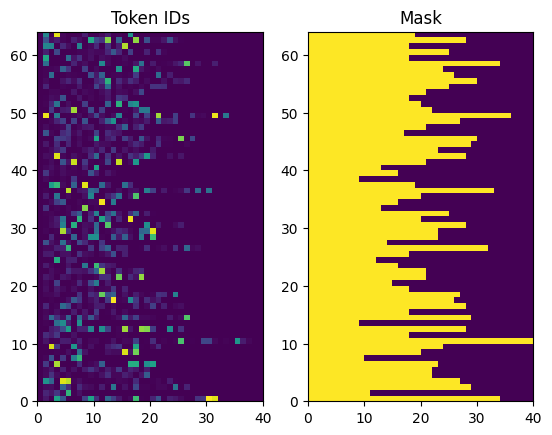

In [27]:
plt.subplot(1, 2, 1)
plt.pcolormesh(example_tokens.to_tensor())
plt.title('Token IDs')

plt.subplot(1, 2, 2)
plt.pcolormesh(example_tokens.to_tensor() != 0)
plt.title('Mask')

# Process the dataset

The process_text function below converts the ``Datasets`` of strings, into 0-padded tensors of token IDs. It also converts from a (``context, target``) pair to an (``(context, target_in), target_out``) pair for training with keras.Model.fit. Keras expects (``inputs, labels``) pairs, the inputs are the (``context, target_in``) and the labels are ``target_out``. The difference between ``target_in`` and ``target_out`` is that they are shifted by one step relative to eachother, so that at each location the label is the next token.

In [28]:
def process_text(context, target):
  context = context_text_processor(context).to_tensor()
  target = target_text_processor(target)
  targ_in = target[:,:-1].to_tensor()
  targ_out = target[:,1:].to_tensor()
  return (context, targ_in), targ_out


train_ds = train_raw.map(process_text, tf.data.AUTOTUNE)
val_ds = val_raw.map(process_text, tf.data.AUTOTUNE)
test_ds = test_raw.map(process_text, tf.data.AUTOTUNE)

In [29]:
for (ex_context_tok, ex_tar_in), ex_tar_out in train_ds.take(1):
  print(ex_context_tok[0, :10].numpy()) 
  print()
  print(ex_tar_in[0, :10].numpy()) 
  print(ex_tar_out[0, :10].numpy())

[   4   26   23   12  113    1   94 2815 7048  443]

[   3   22   29   16 2826 1125 1144  290   64    5]
[  22   29   16 2826 1125 1144  290   64    5  143]


# Encoder decoder model

## Encoder (bidirectional)

In [30]:
ENCODER_EMBEDDING=256
ENCODER_HIDDEN=256
UNITS=256

In [31]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, text_processor, embedding, hidden_size):
    super(Encoder, self).__init__()
    self.text_processor = text_processor
    self.vocab_size = text_processor.vocabulary_size()
    self.embedding = embedding
    self.hidden_size=hidden_size

    # The embedding layer converts tokens to vectors
    self.embedding = tf.keras.layers.Embedding(self.vocab_size, embedding,
                                               mask_zero=True)

    # The RNN layer processes those vectors sequentially.
    self.rnn = tf.keras.layers.Bidirectional(
        merge_mode='sum',
        layer=tf.keras.layers.GRU(hidden_size,
                            # Return the sequence and state
                            return_sequences=True,
                            recurrent_initializer='glorot_uniform'))

  def call(self, x):
    shape_checker = ShapeChecker()
    shape_checker(x, 'batch s')

    # 2. The embedding layer looks up the embedding vector for each token.
    x = self.embedding(x)
    shape_checker(x, 'batch s units')

    # 3. The GRU processes the sequence of embeddings.
    x = self.rnn(x)
    shape_checker(x, 'batch s units')

    # 4. Returns the new sequence of embeddings.
    return x

  def convert_input(self, texts):
    texts = tf.convert_to_tensor(texts)
    if len(texts.shape) == 0:
      texts = tf.convert_to_tensor(texts)[tf.newaxis]
    context = self.text_processor(texts).to_tensor()
    context = self(context)
    return context

In [32]:
# Encode the input sequence.
encoder = Encoder(context_text_processor, 256, 256)
ex_context = encoder(ex_context_tok)

print(f'Context tokens, shape (batch, s): {ex_context_tok.shape}')
print(f'Encoder output, shape (batch, s, units): {ex_context.shape}')

I0000 00:00:1754463374.060072      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


Context tokens, shape (batch, s): (64, 37)
Encoder output, shape (batch, s, units): (64, 37, 256)


In [33]:
encoder

<Encoder name=encoder, built=True>

## Attention layer

You must choose num_heads and key_dim so that
``num_heads`` * ``key_dim`` == your ``decoder_hidden_size``

In [34]:
class CrossAttention(tf.keras.layers.Layer):
  def __init__(self, units, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(key_dim=units, num_heads=1, **kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

  def call(self, x, context):
    shape_checker = ShapeChecker()

    shape_checker(x, 'batch t units')
    shape_checker(context, 'batch s units')

    attn_output, attn_scores = self.mha(
        query=x,
        value=context,
        return_attention_scores=True)

    shape_checker(x, 'batch t units')
    shape_checker(attn_scores, 'batch heads t s')

    # Cache the attention scores for plotting later.
    attn_scores = tf.reduce_mean(attn_scores, axis=1)
    shape_checker(attn_scores, 'batch t s')
    self.last_attention_weights = attn_scores

    x = self.add([x, attn_output])
    x = self.layernorm(x)

    return x

In [35]:
attention_layer = CrossAttention(units=256)

# Attend to the encoded tokens
embed = tf.keras.layers.Embedding(target_text_processor.vocabulary_size(),
                                  output_dim=256, mask_zero=True)
ex_tar_embed = embed(ex_tar_in)

result = attention_layer(ex_tar_embed, ex_context)

print(f'Context sequence, shape (batch, s, units): {ex_context.shape}')
print(f'Target sequence, shape (batch, t, units): {ex_tar_embed.shape}')
print(f'Attention result, shape (batch, t, units): {result.shape}')
print(f'Attention weights, shape (batch, t, s):    {attention_layer.last_attention_weights.shape}')

Context sequence, shape (batch, s, units): (64, 37, 256)
Target sequence, shape (batch, t, units): (64, 41, 256)
Attention result, shape (batch, t, units): (64, 41, 256)
Attention weights, shape (batch, t, s):    (64, 41, 37)


In [36]:
#The attention weights will sum to 1 over the context sequence, at each location in the target sequence.

attention_layer.last_attention_weights[0].numpy().sum(axis=-1)

array([0.9999999 , 1.        , 1.        , 1.        , 1.        ,
       1.0000001 , 0.9999999 , 1.0000001 , 1.        , 0.99999994,
       1.0000001 , 1.        , 0.99999994, 0.99999994, 1.        ,
       1.        , 1.        , 0.99999994, 1.0000001 , 1.        ,
       1.0000001 , 1.        , 0.9999999 , 0.9999999 , 0.9999999 ,
       0.9999999 , 0.9999999 , 0.9999999 , 0.9999999 , 0.9999999 ,
       0.9999999 , 0.9999999 , 0.9999999 , 0.9999999 , 0.9999999 ,
       0.9999999 , 0.9999999 , 0.9999999 , 0.9999999 , 0.9999999 ,
       0.9999999 ], dtype=float32)

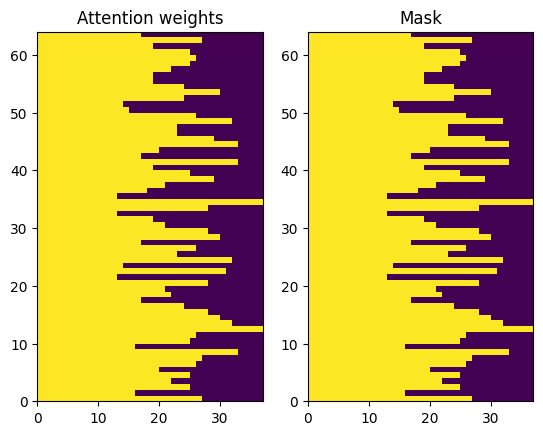

In [37]:
# Here are the attention weights across the context sequences at t=0:
attention_weights = attention_layer.last_attention_weights
mask=(ex_context_tok != 0).numpy()

plt.subplot(1, 2, 1)
plt.pcolormesh(mask*attention_weights[:, 0, :])
plt.title('Attention weights')

plt.subplot(1, 2, 2)
plt.pcolormesh(mask)
plt.title('Mask');

Because of the small-random initialization the attention weights are initially all close to 1/(sequence_length). The model will learn to make these less uniform as training progresses.

## Decoder

In [38]:
class Decoder(tf.keras.layers.Layer):
  @classmethod
  def add_method(cls, fun):
    setattr(cls, fun.__name__, fun)
    return fun

  def __init__(self, text_processor, embedding, hidden_size):
    super(Decoder, self).__init__()
    self.text_processor = text_processor
    self.vocab_size = text_processor.vocabulary_size()
    self.word_to_id = tf.keras.layers.StringLookup(
        vocabulary=text_processor.get_vocabulary(),
        mask_token='', oov_token='[UNK]')
    self.id_to_word = tf.keras.layers.StringLookup(
        vocabulary=text_processor.get_vocabulary(),
        mask_token='', oov_token='[UNK]',
        invert=True)
    self.start_token = self.word_to_id('[START]')
    self.end_token = self.word_to_id('[END]')

    self.embedding = embedding
    self.hidden_size = hidden_size


    # 1. The embedding layer converts token IDs to vectors
    self.embedding = tf.keras.layers.Embedding(self.vocab_size,
                                               embedding, mask_zero=True)

    # 2. The RNN keeps track of what's been generated so far.
    self.rnn = tf.keras.layers.GRU(hidden_size,
                                   return_sequences=True,
                                   return_state=True,
                                   recurrent_initializer='glorot_uniform', reset_after=False)

    # 3. The RNN output will be the query for the attention layer.
    self.attention = CrossAttention(hidden_size)

    # 4. This fully connected layer produces the logits for each
    # output token.
    self.output_layer = tf.keras.layers.Dense(self.vocab_size)

In [39]:
@Decoder.add_method
def call(self,
         context, x,
         state=None,
         return_state=False):  
  shape_checker = ShapeChecker()
  shape_checker(x, 'batch t')
  shape_checker(context, 'batch s units')

  # 1. Lookup the embeddings
  x = self.embedding(x)
  shape_checker(x, 'batch t units')

  # 2. Process the target sequence.
  x, state = self.rnn(x, initial_state=state)
  shape_checker(x, 'batch t units')

  # 3. Use the RNN output as the query for the attention over the context.
  x = self.attention(x, context)
  self.last_attention_weights = self.attention.last_attention_weights
  shape_checker(x, 'batch t units')
  shape_checker(self.last_attention_weights, 'batch t s')

  # Step 4. Generate logit predictions for the next token.
  logits = self.output_layer(x)
  shape_checker(logits, 'batch t target_vocab_size')

  if return_state:
    return logits, state
  else:
    return logits

In [40]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [41]:
# Test with a simple GRU
test_gru = tf.keras.layers.GRU(256, return_sequences=True, return_state=True, reset_after=False) #reset after fixes the dimension bug on GPU
test_input = tf.random.normal((64, 14, 256))
test_output = test_gru(test_input)
print(f"Test GRU output length: {len(test_output) if isinstance(test_output, tuple) else 'not tuple'}")

Test GRU output length: 2


In [42]:
DECODER_EMBEDDING=256
DECODER_HIDDEN=256

In [43]:
decoder=Decoder(target_text_processor, 256, 256)

In [44]:
logits = decoder(ex_context, ex_tar_in)

print(f'encoder output shape: (batch, s, units) {ex_context.shape}')
print(f'input target tokens shape: (batch, t) {ex_tar_in.shape}')
print(f'logits shape shape: (batch, target_vocabulary_size) {logits.shape}')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'decoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


encoder output shape: (batch, s, units) (64, 37, 256)
input target tokens shape: (batch, t) (64, 41)
logits shape shape: (batch, target_vocabulary_size) (64, 41, 8000)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'cross_attention_1' (of type CrossAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [45]:
tf.config.run_functions_eagerly(False)

# Inference methods

In [46]:
@Decoder.add_method
def get_initial_state(self, context):
    batch_size = tf.shape(context)[0]
    start_tokens = tf.fill([batch_size, 1], self.start_token)
    done = tf.zeros([batch_size, 1], dtype=tf.bool)
    # make a [batch_size, hidden_size] zero tensor directly
    initial_state = tf.zeros([batch_size, self.rnn.units], dtype=tf.float32)
    return start_tokens, done, initial_state

In [47]:
@Decoder.add_method
def tokens_to_text(self, tokens):
  words = self.id_to_word(tokens)
  result = tf.strings.reduce_join(words, axis=-1, separator=' ')
  result = tf.strings.regex_replace(result, '^ *\[START\] *', '')
  result = tf.strings.regex_replace(result, ' *\[END\] *$', '')
  return result

In [48]:
@Decoder.add_method
def get_next_token(self, context, next_token, done, state, temperature = 0.0):
  logits, state = self(
    context, next_token,
    state = state,
    return_state=True) 

  if temperature == 0.0:
    next_token = tf.argmax(logits, axis=-1)
  else:
    logits = logits[:, -1, :]/temperature
    next_token = tf.random.categorical(logits, num_samples=1)

  # If a sequence produces an `end_token`, set it `done`
  done = done | (next_token == self.end_token)
  # Once a sequence is done it only produces 0-padding.
  next_token = tf.where(done, tf.constant(0, dtype=tf.int64), next_token)

  return next_token, done, state

In [49]:
# Setup the loop variables.
next_token, done, state = decoder.get_initial_state(ex_context)
tokens = []

for n in range(10):
  # Run one step.
  next_token, done, state = decoder.get_next_token(
      ex_context, next_token, done, state, temperature=1.0)
  # Add the token to the output.
  tokens.append(next_token)

# Stack all the tokens together.
tokens = tf.concat(tokens, axis=-1) # (batch, t)

# Convert the tokens back to a a string
result = decoder.tokens_to_text(tokens)
result[:3].numpy()

array([b'perayaan martino kontribusi keunggulan bengkel atlantik meluap panorama terencana force',
       b'jan berada penembak normal komentar 2007 lithuania estonia menginginkan gunung',
       b'ide benediktus wisuda tertib city bertanggungjawab adam carlisle kedutaan mengejar'],
      dtype=object)

# Model (by subclassing)

In [50]:
class Translator(tf.keras.Model):
    @classmethod
    def add_method(cls, fun):
        setattr(cls, fun.__name__, fun)
        return fun

    def __init__(self, context_text_processor, target_text_processor, embedding_size=256, hidden_size=256, **kwargs):
        # Call super().__init__() with only valid keras.Model arguments
        super().__init__(**kwargs)
        
        # Build the encoder and decoder
        encoder = Encoder(context_text_processor, embedding_size, hidden_size)
        decoder = Decoder(target_text_processor, embedding_size, hidden_size)

        self.encoder = encoder
        self.decoder = decoder

    def build_model(self, context_shape, target_shape):
        """Build the model with specified input shapes"""
        # Create dummy inputs with the specified shapes
        context_input = tf.keras.Input(shape=context_shape[1:], name='context')
        target_input = tf.keras.Input(shape=target_shape[1:], name='target')
        
        # Call the model to build all layers
        _ = self([context_input, target_input])

    def call(self, inputs):
        context, x = inputs
        context = self.encoder(context)
        logits = self.decoder(context, x)

        #TODO(b/250038731): remove this
        try:
            # Delete the keras mask, so keras doesn't scale the loss+accuracy. 
            del logits._keras_mask
        except AttributeError:
            pass

        return logits

In [51]:
model = Translator(context_text_processor, target_text_processor, embedding_size=256, hidden_size=256)

logits = model((ex_context_tok, ex_tar_in))

print(f'Context tokens, shape: (batch, s, units) {ex_context_tok.shape}')
print(f'Target tokens, shape: (batch, t) {ex_tar_in.shape}')
print(f'logits, shape: (batch, t, target_vocabulary_size) {logits.shape}')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'decoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'cross_attention_2' (of type CrossAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Context tokens, shape: (batch, s, units) (64, 37)
Target tokens, shape: (batch, t) (64, 41)
logits, shape: (batch, t, target_vocabulary_size) (64, 41, 8000)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'decoder_1' (of type Decoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


## Functional API model for summary

In [52]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, GRU,
    MultiHeadAttention, Add, LayerNormalization, Dense
)
from tensorflow.keras.models import Model

# Hyper‑parameters
EMB_DIM    = 256
HIDDEN_DIM = 256
VOCAB_CTX  = context_text_processor.vocabulary_size()
VOCAB_TGT  = target_text_processor.vocabulary_size()
batchsz = 64

# 1) Define the two inputs (already tokenized & padded to integer IDs)
context_input = Input(batch_shape=(batchsz,10), dtype='int64', name='context_input')
target_input  = Input(batch_shape=(batchsz,10), dtype='int64', name='target_input')

# 2) Encoder
#  - embedding
ctx_emb = Embedding(input_dim=VOCAB_CTX,
                    output_dim=EMB_DIM,
                    mask_zero=True,
                    name='encoder_embedding')(context_input)
#  - bidirectional GRU (sum merge)
ctx_enc = Bidirectional(
    GRU(HIDDEN_DIM,
        return_sequences=True,
        recurrent_initializer='glorot_uniform'),
    merge_mode='sum',
    name='encoder_rnn'
)(ctx_emb)

# 3) Decoder
#  - embedding
tgt_emb = Embedding(input_dim=VOCAB_TGT,
                    output_dim=EMB_DIM,
                    mask_zero=True,
                    name='decoder_embedding')(target_input)
#  - GRU
tgt_hidden = GRU(HIDDEN_DIM,
                 return_sequences=True,
                 recurrent_initializer='glorot_uniform',
                 name='decoder_rnn'
)(tgt_emb)

# 4) Cross‑attention (1 head, key/query dim = HIDDEN_DIM)
attn_out = MultiHeadAttention(num_heads=1,
                              key_dim=HIDDEN_DIM,
                              name='cross_attention')(
    query=tgt_hidden,
    value=ctx_enc
)

# 5) Residual & layer‐norm
resid = Add(name='attn_residual')([tgt_hidden, attn_out])
norm = LayerNormalization(name='attn_layernorm')(resid)

# 6) Final projection to logits
logits = Dense(VOCAB_TGT, name='output_dense')(norm)

# 7) Build the model
func_model = Model([context_input, target_input], logits,
                   name='FunctionalSeq2Seq')
func_model.summary(line_length=100, positions=[0.2, 0.4, 0.5, 0.89])

Model: "FunctionalSeq2Seq"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape        ┃    Param # ┃ Connected to                           ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ target_input         │ (64, 10)            │          0 │ -                                      │
│ (InputLayer)         │                     │            │                                        │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ context_input        │ (64, 10)            │          0 │ -                                      │
│ (InputLayer)         │                     │            │                                        │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ decoder_embedding    │ (64, 10, 256)       │  2,048,000 │ target_input[0][0]                     │
│ (Embedding)          │                     │            │                                        │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ not_equal_1          │ (64, 10)            │          0 │ target_input[0][0]                     │
│ (NotEqual)           │                     │            │                                        │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ encoder_embedding    │ (64, 10, 256)       │  2,048,000 │ context_input[0][0]                    │
│ (Embedding)          │                     │            │                                        │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ not_equal (NotEqual) │ (64, 10)            │          0 │ context_input[0][0]                    │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ decoder_rnn (GRU)    │ (64, 10, 256)       │    394,752 │ decoder_embedding[0][0],               │
│                      │                     │            │ not_equal_1[0][0]                      │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ encoder_rnn          │ (64, 10, 256)       │    789,504 │ encoder_embedding[0][0],               │
│ (Bidirectional)      │                     │            │ not_equal[0][0]                        │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ cross_attention      │ (64, 10, 256)       │    263,168 │ decoder_rnn[0][0], not_equal_1[0][0],  │
│ (MultiHeadAttention) │                     │            │ encoder_rnn[0][0], not_equal[0][0]     │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ attn_residual (Add)  │ (64, 10, 256)       │          0 │ decoder_rnn[0][0],                     │
│                      │                     │            │ cross_attention[0][0]                  │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ attn_layernorm       │ (64, 10, 256)       │        512 │ attn_residual[0][0]                    │
│ (LayerNormalization) │                     │            │                                        │
├──────────────────────┼─────────────────────┼────────────┼────────────────────────────────────────┤
│ output_dense (Dense) │ (64, 10, 8000)      │  2,056,000 │ attn_layernorm[0][0]                   │
└──────────────────────┴─────────────────────┴────────────┴────────────────────────────────────────┘

 Total params: 7,599,936 (28.99 MB)

 Trainable params: 7,599,936 (28.99 MB)

 Non-trainable params: 0 (0.00 B)

# Training

In [53]:
def masked_loss(y_true, y_pred):
    # Calculate the loss for each item in the batch.
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction='none')
    loss = loss_fn(y_true, y_pred)

    # Mask off the losses on padding.
    mask = tf.cast(y_true != 0, loss.dtype)
    loss *= mask

    # Return the total.
    return tf.reduce_sum(loss)/tf.reduce_sum(mask)


def masked_acc(y_true, y_pred):
    # Calculate the loss for each item in the batch.
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.cast(y_pred, y_true.dtype)

    match = tf.cast(y_true == y_pred, tf.float32)
    mask = tf.cast(y_true != 0, tf.float32)

    return tf.reduce_sum(match)/tf.reduce_sum(mask)

In [54]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=masked_loss, 
              metrics=[masked_acc, masked_loss])

In [55]:
vocab_size = 1.0 * target_text_processor.vocabulary_size()

{"expected_loss": tf.math.log(vocab_size).numpy(),
 "expected_acc": 1/vocab_size}

{'expected_loss': 8.987197, 'expected_acc': 0.000125}

In [56]:
print(model.optimizer.learning_rate)

<Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0010000000474974513>


In [57]:
model.evaluate(val_ds, steps=20, return_dict=True)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 8.9943 - masked_acc: 2.2180e-05 - masked_loss: 8.9943


{'loss': 8.994722366333008,
 'masked_acc': 3.709198790602386e-05,
 'masked_loss': 8.994722366333008}

In [58]:
history = model.fit(
    train_ds, 
    epochs=100,
    validation_data=val_ds,
    validation_steps = 20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3)])

Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 89ms/step - loss: 6.7403 - masked_acc: 0.1181 - masked_loss: 6.7403 - val_loss: 5.2592 - val_masked_acc: 0.2214 - val_masked_loss: 5.2592
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - loss: 4.9237 - masked_acc: 0.2597 - masked_loss: 4.9237 - val_loss: 4.2969 - val_masked_acc: 0.3112 - val_masked_loss: 4.2969
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 3.5953 - masked_acc: 0.3896 - masked_loss: 3.5953 - val_loss: 3.5421 - val_masked_acc: 0.4057 - val_masked_loss: 3.5421
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 2.5648 - masked_acc: 0.5103 - masked_loss: 2.5648 - val_loss: 3.2422 - val_masked_acc: 0.4379 - val_masked_loss: 3.2422
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - loss: 1.8597 - masked_acc: 0.6070 - masked_loss: 1.8597 - val_loss: 3.1831 - val_masked_acc: 0.4573 - val_masked_loss: 3.1831
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 1.4049 - masked_acc: 0

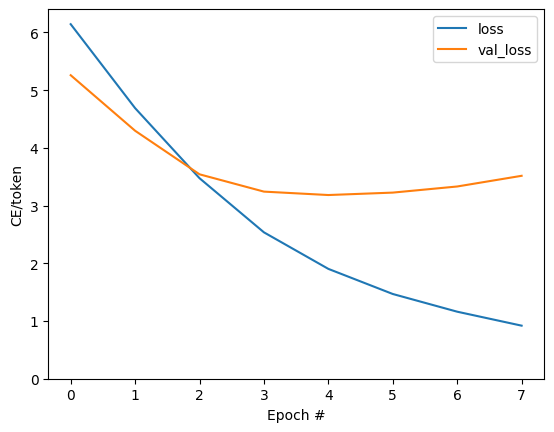

In [59]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch #')
plt.ylabel('CE/token')
plt.legend()

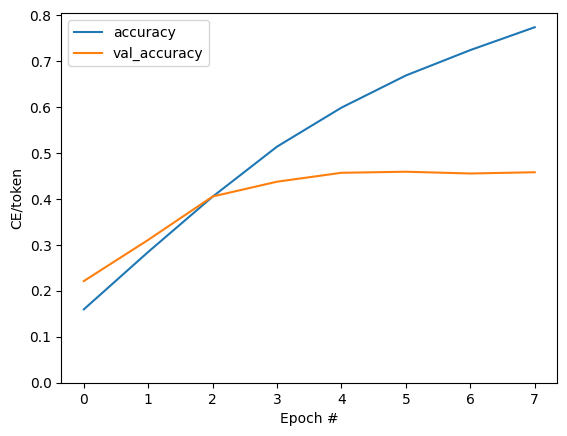

In [60]:
plt.plot(history.history['masked_acc'], label='accuracy')
plt.plot(history.history['val_masked_acc'], label='val_accuracy')
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch #')
plt.ylabel('CE/token')
plt.legend()

# Translate

In [61]:
@Translator.add_method
def translate(self,
              texts, *,
              max_length=50,
              temperature=0.0):
  # Process the input texts
  context = self.encoder.convert_input(texts)
  batch_size = tf.shape(texts)[0]

  # Setup the loop inputs
  tokens = []
  attention_weights = []
  next_token, done, state = self.decoder.get_initial_state(context)

  for _ in range(max_length):
    # Generate the next token
    next_token, done, state = self.decoder.get_next_token(
        context, next_token, done,  state, temperature)

    # Collect the generated tokens
    tokens.append(next_token)
    attention_weights.append(self.decoder.last_attention_weights)

    if tf.executing_eagerly() and tf.reduce_all(done):
      break

  # Stack the lists of tokens and attention weights.
  tokens = tf.concat(tokens, axis=-1)   # t*[(batch 1)] -> (batch, t)
  self.last_attention_weights = tf.concat(attention_weights, axis=1)  # t*[(batch 1 s)] -> (batch, t s)

  result = self.decoder.tokens_to_text(tokens)
  return result

In [62]:
result = model.translate(['The ball is two meters above the table.'])
result[0].numpy().decode()

'bola itu dua meter di atas meja di sebelah . '

In [63]:
@Translator.add_method
def plot_attention(self, text, fontsize=14, **kwargs):
  assert isinstance(text, str)
  output = self.translate([text], **kwargs)
  output = output[0].numpy().decode()

  attention = self.last_attention_weights[0]

  context = tf_lower_and_split_punct_eng(text)
  context = context.numpy().decode().split()

  output = tf_lower_and_split_punct_id(output)
  output = output.numpy().decode().split()[1:]

  fig = plt.figure(figsize=(10, 10))
  ax = fig.add_subplot(1, 1, 1)

  ax.matshow(attention, cmap='viridis', vmin=0.0)

  fontdict = {'fontsize': fontsize}

  ax.set_xticklabels([''] + context, fontdict=fontdict, rotation=90)
  ax.set_yticklabels([''] + output, fontdict=fontdict)

  ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
  ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

  ax.set_xlabel('Input text')
  ax.set_ylabel('Output text')

In [64]:
import matplotlib.ticker as ticker

@Translator.add_method
def plot_attention_long(self, text, fontsize=14, max_fontsize=20, **kwargs):
    # 1) translate + grab weights
    output = self.translate([text], **kwargs)[0].numpy().decode()
    attn   = self.last_attention_weights[0]
    
    # 2) tokenize
    src = tf_lower_and_split_punct_eng(text).numpy().decode().split()
    tgt = tf_lower_and_split_punct_id(output).numpy().decode().split()[1:]
    
    # 3) dynamic sizing
    w, h = len(src)*0.3, len(tgt)*0.3
    fig, ax = plt.subplots(figsize=(max(10, w), max(10, h)))
    
    ax.matshow(attn, cmap='viridis', vmin=0.0)
    # smaller font if too many tokens
    fs = min(fontsize, max_fontsize, 200/len(src))
    fontdict = {'fontsize': fs}
    
    ax.set_xticklabels([''] + src, fontdict=fontdict, rotation=90)
    ax.set_yticklabels([''] + tgt, fontdict=fontdict)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    
    plt.tight_layout()
    plt.show()


In [65]:
import matplotlib.ticker as ticker

@Translator.add_method
def plot_attention_chunks(self, text, chunk_size=30, fontsize=12, **kwargs):
    # 1) translate + tokenize
    output = self.translate([text], **kwargs)[0].numpy().decode()
    src = tf_lower_and_split_punct_eng(text).numpy().decode().split()
    tgt = tf_lower_and_split_punct_id(output).numpy().decode().split()[1:]
    attn = self.last_attention_weights[0]
    # if you have a heads dimension, collapse it:
    if attn.ndim == 3:
        attn = attn.mean(axis=0)
    attn = attn.numpy() if hasattr(attn, "numpy") else attn  # ensure numpy

    # 2) loop over chunks
    for start in range(0, len(src), chunk_size):
        end = min(start + chunk_size, len(src))
        src_chunk = src[start:end]
        sub_attn = attn[:, start:end]  # shape (len(tgt), len(src_chunk))

        fig, ax = plt.subplots(figsize=(max(6, len(src_chunk)*0.3),
                                        max(6, len(tgt)*0.3)))
        im = ax.matshow(sub_attn, cmap='viridis', vmin=0.0)

        # 3) set tick locations and labels
        ax.set_xticks(np.arange(len(src_chunk)))
        ax.set_xticklabels(src_chunk, rotation=90, fontsize=fontsize)
        ax.set_yticks(np.arange(len(tgt)))
        ax.set_yticklabels(tgt, fontsize=fontsize)

        # 4) tighten up
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.title(f"Source tokens {start}:{end}")
        plt.tight_layout()
        plt.show()


/tmp/ipykernel_19/3363796835.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + context, fontdict=fontdict, rotation=90)
/tmp/ipykernel_19/3363796835.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + output, fontdict=fontdict)


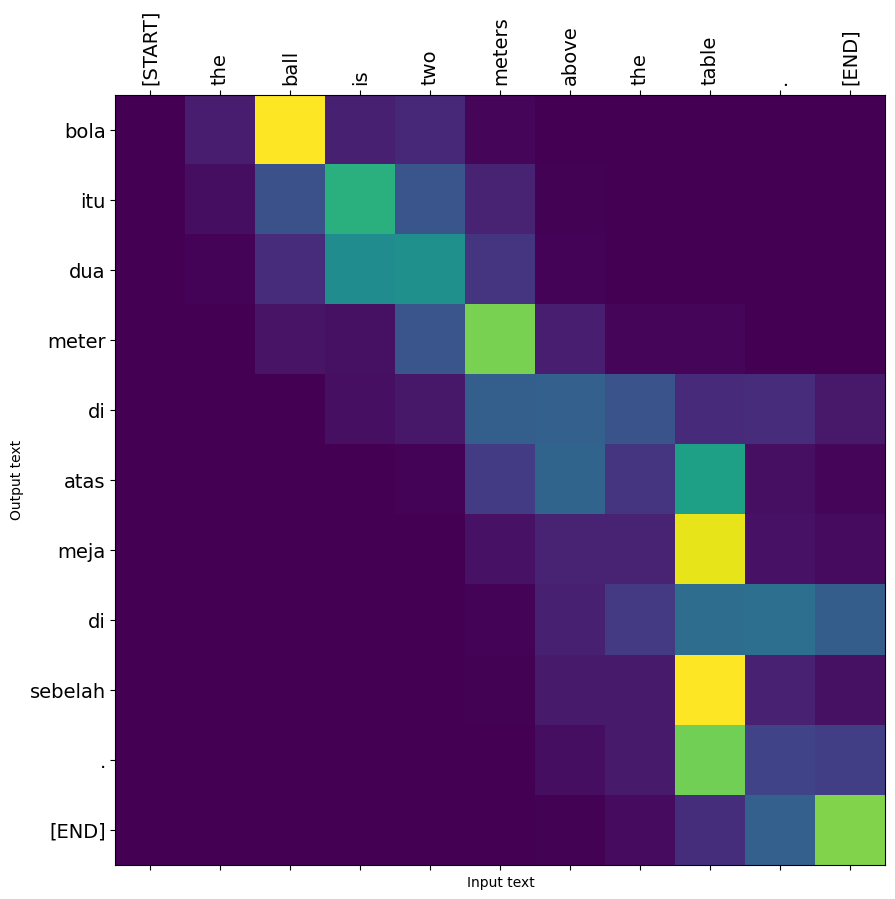

In [66]:
model.plot_attention('The ball is two meters above the table.') 

/tmp/ipykernel_19/3363796835.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + context, fontdict=fontdict, rotation=90)
/tmp/ipykernel_19/3363796835.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + output, fontdict=fontdict)


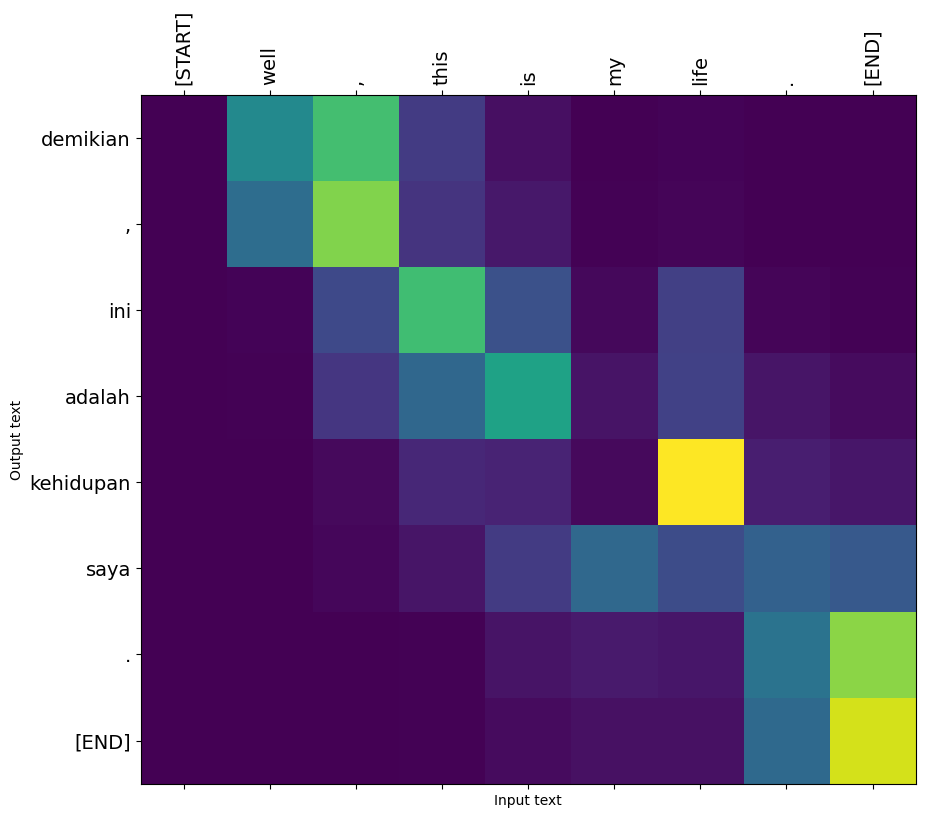

In [67]:
model.plot_attention('Well, this is my life.') # Are you still home

/tmp/ipykernel_19/3363796835.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + context, fontdict=fontdict, rotation=90)
/tmp/ipykernel_19/3363796835.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + output, fontdict=fontdict)


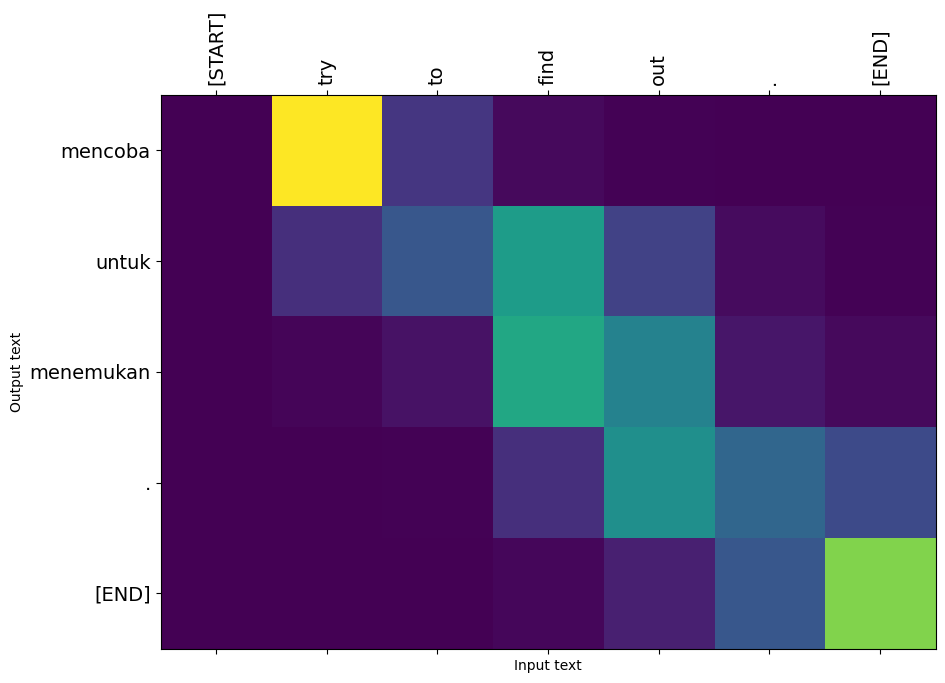

In [68]:
model.plot_attention('Try to find out.') # Are you still home

The short sentences often work well, but if the input is too long the model literally loses focus and stops providing reasonable predictions. There are two main reasons for this:

The model was trained with teacher-forcing feeding the correct token at each step, regardless of the model's predictions. The model could be made more robust if it were sometimes fed its own predictions.
The model only has access to its previous output through the RNN state. If the RNN state looses track of where it was in the context sequence there's no way for the model to recover. Transformers improve on this by letting the decoder look at what it has output so far.

The raw data is sorted by length, so try translating the longest sequence:

In [69]:
long_contexts, long_targets = get_longest_with_targets(context_raw, target_raw, 3)

In [70]:
long_text = long_contexts[0]

import textwrap
print('Expected output:\n', '\n'.join(textwrap.wrap(long_targets[0])))

Expected output:
 Pengadilan Sipil di Propinsi Quang Ninh utara menjatuhkan hukuman
setelah 4 hari sidang, dan menyita 19. 600 jeans yang digunakan untuk
penyelundupan, sebagai aset sebesar 1,5 juta Dolar Hongkong (278.262
Yuan, 10.485 Dolar Amerika).


/tmp/ipykernel_19/548347770.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + src, fontdict=fontdict, rotation=90)
/tmp/ipykernel_19/548347770.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + tgt, fontdict=fontdict)


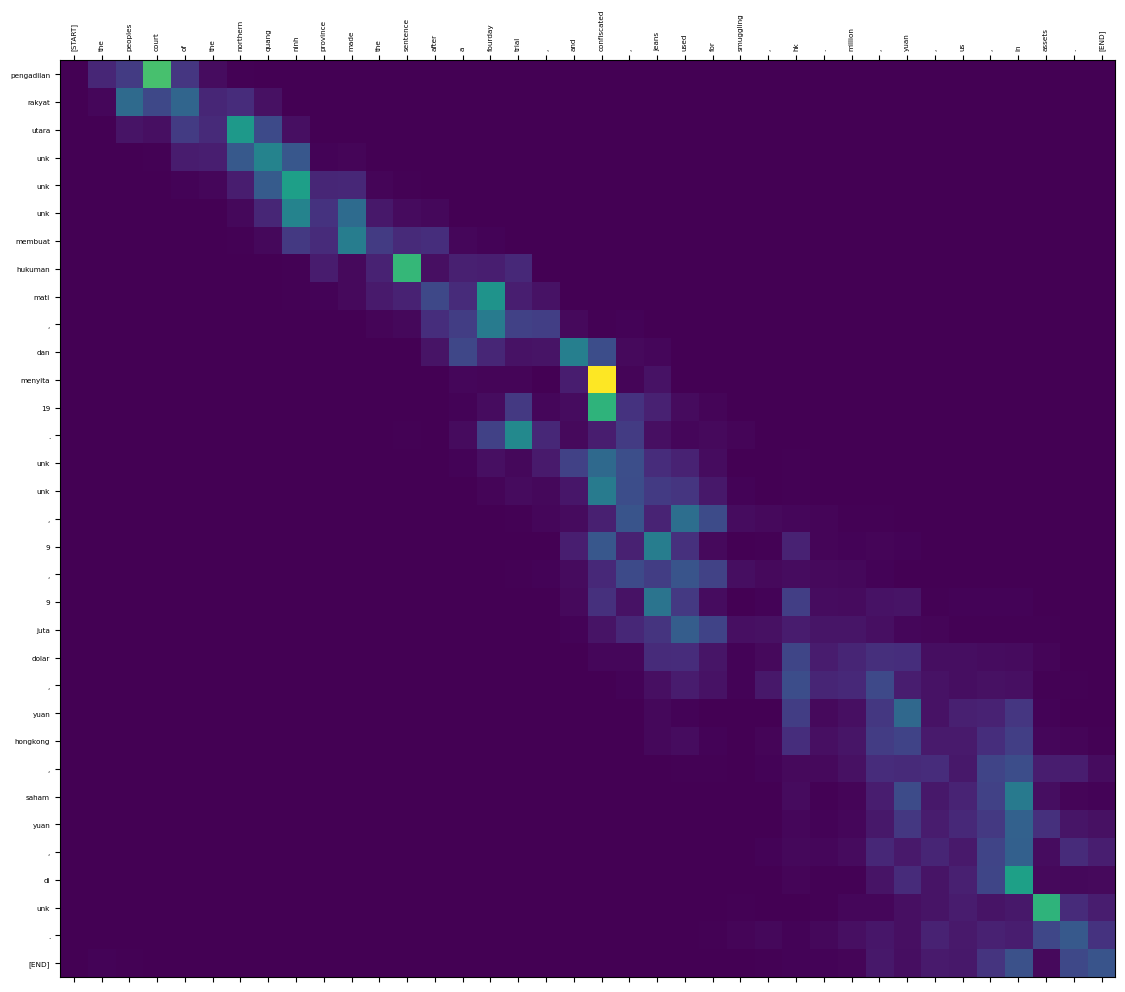

In [71]:
model.plot_attention_long(long_text)

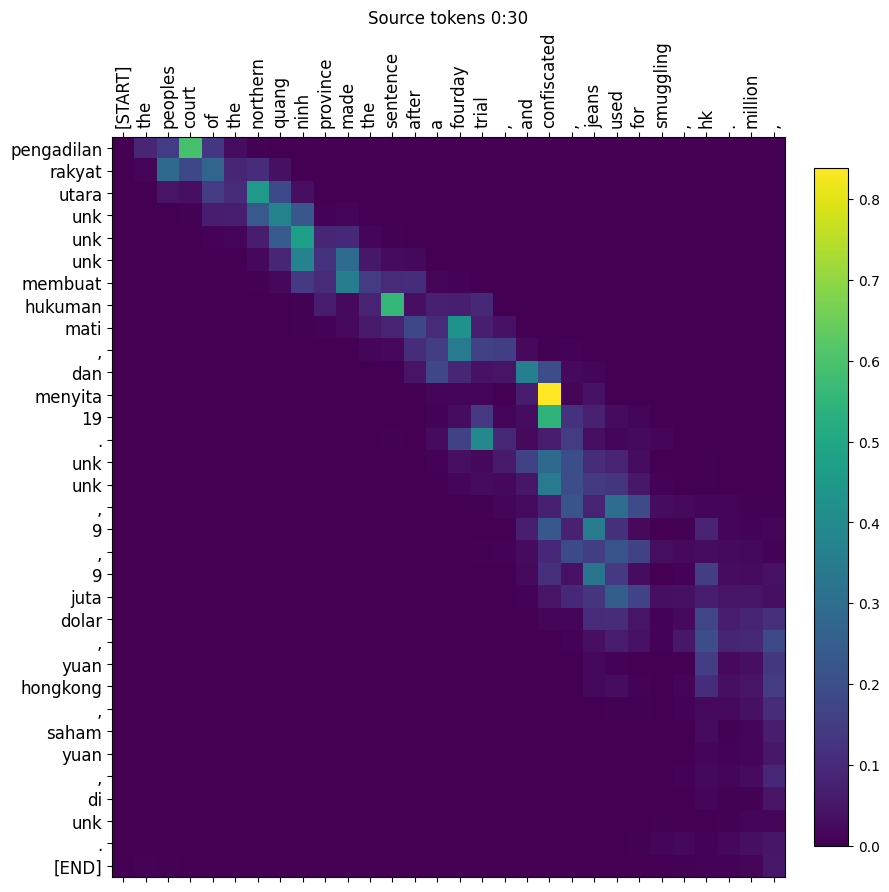

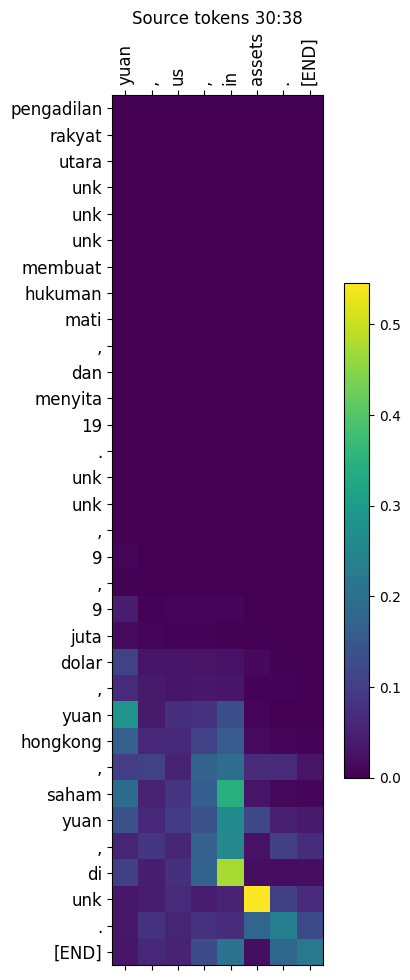

In [72]:
model.plot_attention_chunks(long_text)

In [73]:
long_text2 = long_contexts[1]

print('Expected output:\n', '\n'.join(textwrap.wrap(long_targets[1])))

Expected output:
 Juanita "Toni" Huntingdon, 41, membantu mengatur rumah bordil
Birmingham dan bertindak sebagai resepsionis pada 2 posisi tersebut
dan memasukkan pembelaan bersalah atas 5 tuduhan pada mengendalikan
prostitusi untuk keuntungan.


/tmp/ipykernel_19/548347770.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + src, fontdict=fontdict, rotation=90)
/tmp/ipykernel_19/548347770.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + tgt, fontdict=fontdict)


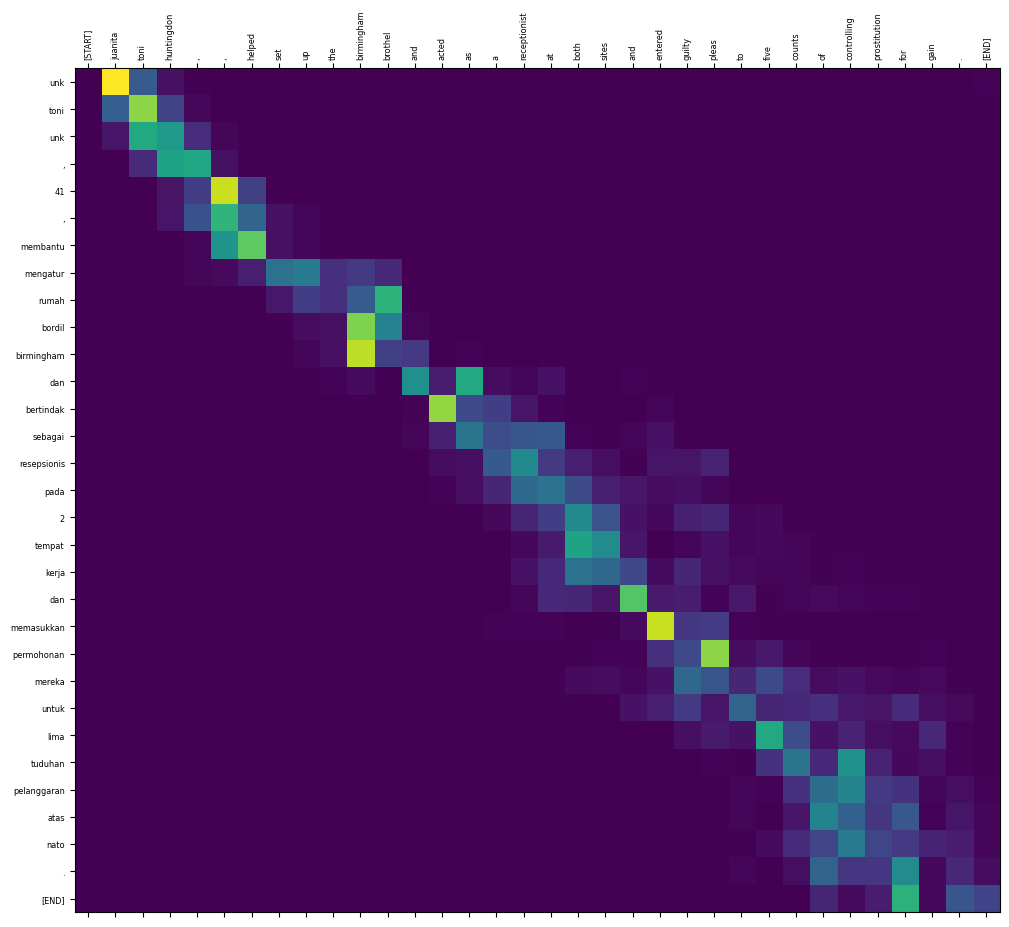

In [74]:
model.plot_attention_long(long_text2)

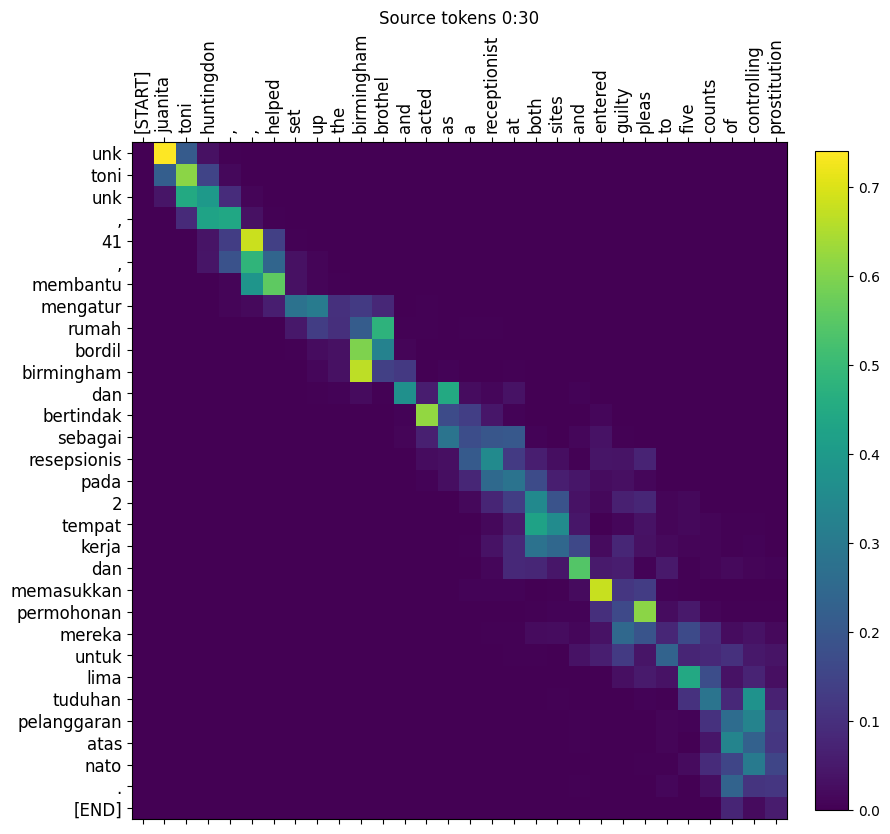

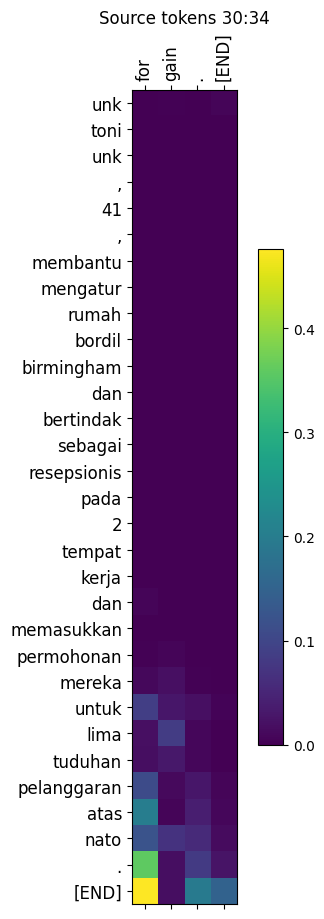

In [75]:
model.plot_attention_chunks(long_text2)

In [76]:
long_text3 = long_contexts[2]

print('Expected output:\n', '\n'.join(textwrap.wrap(long_targets[2])))

Expected output:
 Dokumen tersebut disebarkan di Santo Domingo de Guzman, diantara
persiapan konferensi tentang rekonstruksi Haiti, yang akan berlangsung
pada 11 Maret yang akan datang di New York.


/tmp/ipykernel_19/548347770.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + src, fontdict=fontdict, rotation=90)
/tmp/ipykernel_19/548347770.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + tgt, fontdict=fontdict)


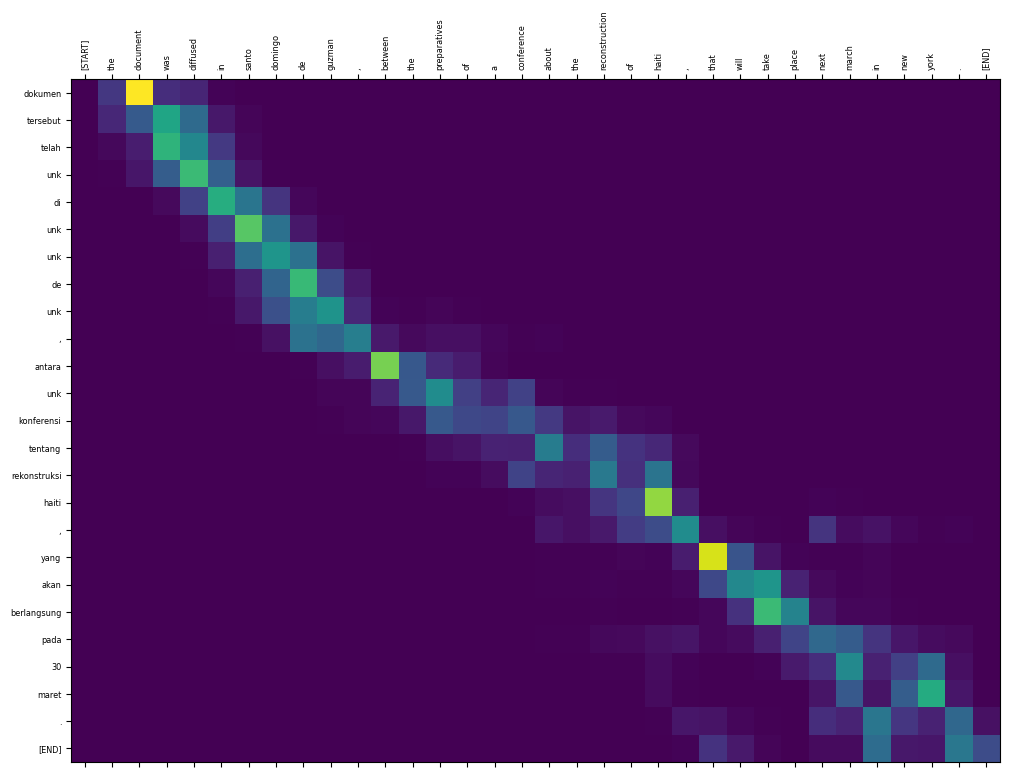

In [77]:
model.plot_attention_long(long_text3)

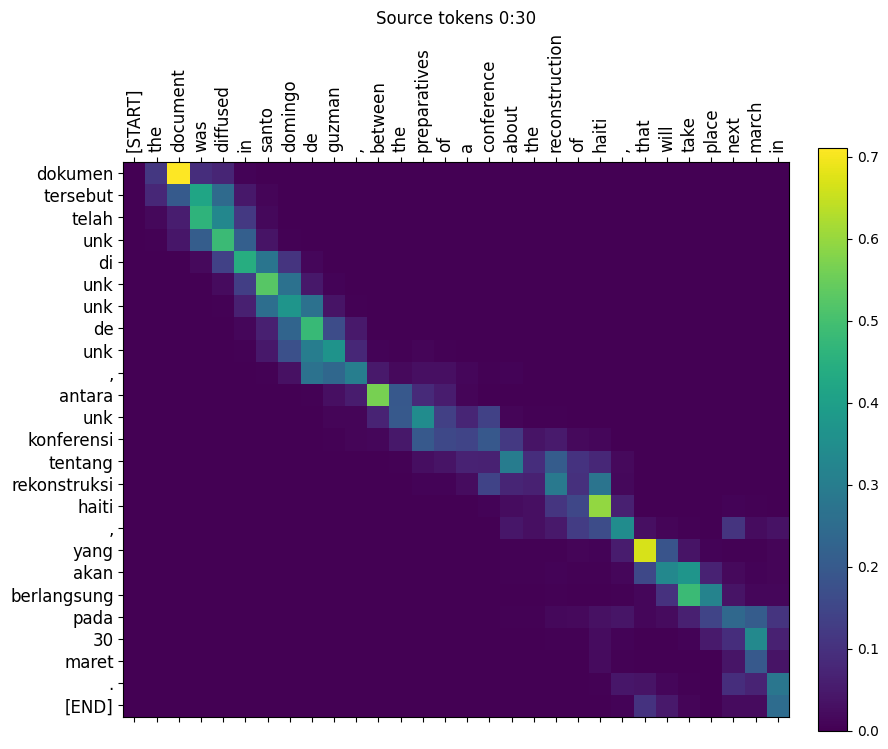

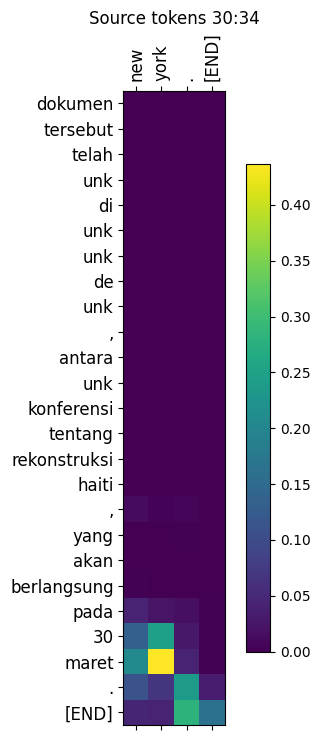

In [78]:
model.plot_attention_chunks(long_text3)

In [79]:
inputs = [
    'The ball is two meters above the ground.', 
    'He hides under the table.',
    'There was a police five feet on his right.'
]

In [80]:
%%time
for t in inputs:
  print(model.translate([t])[0].numpy().decode())

print()

bola itu dua meter di atas tanah . 
dia [UNK] di samping wajah . 
ada 5 tembakan 5 kaki atas [UNK] . 

CPU times: user 815 ms, sys: 14.7 ms, total: 829 ms
Wall time: 808 ms


In [81]:
# 1) Install NLTK and download its BLEU module (if you haven’t already)
!pip install nltk
import nltk
nltk.download('punkt')  # for tokenization

from nltk.translate.bleu_score import corpus_bleu
import tqdm

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [82]:
# without tqdm
# def get_corpus_bleu(ds_set):
#     hypotheses = []
#     references = []
    
#     vocab_list = context_text_processor.get_vocabulary()
    
    
#     for (context_tok, targ_in), targ_out in ds_set:
#         # a) Convert token tensors back to raw strings:
#         #    model.translate wants raw strings, so re-use your translate method
    
#         source_texts = []
#         for ids in context_tok.numpy():        # ids: a 1‑D NumPy array
#             words = [vocab_list[int(i)]       # cast each i to a Python int
#                      for i in ids if i != 0]  # (optionally skip padding)
#             source_texts.append(" ".join(words))
#         preds = model.translate(source_texts, max_length=100).numpy()
#         # preds is a [batch,] array of bytes; decode and split:
#         batch_hyps = [p.decode().split() for p in preds]
    
#         # b) Get the reference strings (targ_out is token IDs, one step ahead):
#         #    we need to strip START/END and padding zeros:
#         vocab = target_text_processor.get_vocabulary()
#         batch_refs = []
#         for seq in targ_out.numpy():
#             # find non-zero tokens, map back to words, strip [END]
#             words = [vocab[i] for i in seq if i != 0]
#             # drop the START token
#             if words and words[0] == "[START]":
#                 words = words[1:]
#             # drop anything after [END]
#             if "[END]" in words:
#                 words = words[:words.index("[END]")]
#             batch_refs.append(words)
    
#         # c) accumulate
#         hypotheses.extend(batch_hyps)
#         # corpus_bleu expects a list-of-lists-of-references:
#         references.extend([[ref] for ref in batch_refs])
    
#     bleu_score = corpus_bleu(references, hypotheses) * 100
#     return hypotheses, references, bleu_score
        



In [83]:
def get_corpus_bleu(ds_set):
    hypotheses = []
    references = []

    src_vocab = context_text_processor.get_vocabulary()
    tgt_vocab = target_text_processor.get_vocabulary()

    # try to infer number of batches
    try:
        total_batches = tf.data.experimental.cardinality(ds_set).numpy()
        if total_batches == tf.data.experimental.INFINITE_CARDINALITY:
            total_batches = None
    except:
        total_batches = None
    
    # wrap the iteration in tqdm
    for (context_tok, targ_in), targ_out in tqdm.tqdm(ds_set,
                                                total=total_batches,
                                                desc="BLEU eval"):
        # decode source strings
        source_texts = []
        for ids in context_tok.numpy():
            words = [src_vocab[int(i)] for i in ids if i != 0]
            source_texts.append(" ".join(words))

        # get your model’s predictions
        preds = model.translate(source_texts, max_length=100).numpy()
        batch_hyps = [p.decode().split() for p in preds]

        # decode references
        batch_refs = []
        for seq in targ_out.numpy():
            words = [tgt_vocab[i] for i in seq if i != 0]
            if words and words[0] == "[START]":
                words = words[1:]
            if "[END]" in words:
                words = words[:words.index("[END]")]
            batch_refs.append(words)

        hypotheses.extend(batch_hyps)
        # corpus_bleu wants a list of list-of-refs
        references.extend([[ref] for ref in batch_refs])

    bleu_score = corpus_bleu(references, hypotheses) * 100
    return hypotheses, references, bleu_score

In [84]:
val_hypotheses, val_references, val_corpus_bleu = get_corpus_bleu(val_ds)

BLEU eval: 100%|██████████| 26/26 [00:30<00:00,  1.17s/it]


In [85]:
print("Val BLEU: ",val_corpus_bleu)

Val BLEU:  15.007836258641651


In [86]:
train_hypotheses, train_references, train_corpus_bleu = get_corpus_bleu(train_ds)

BLEU eval: 100%|██████████| 203/203 [04:12<00:00,  1.24s/it]


In [87]:
print("Train BLEU: ",train_corpus_bleu)

Train BLEU:  47.218443519286865


In [88]:
test_hypotheses, test_references, test_corpus_bleu = get_corpus_bleu(test_ds)

BLEU eval: 100%|██████████| 26/26 [00:29<00:00,  1.12s/it]


In [89]:
print("Test BLEU: ",test_corpus_bleu)

Test BLEU:  14.725921848028642
